In [11]:
import pandas as pd
import pyreadstat
import seaborn as sns
import matplotlib.pyplot as plt

df, meta = pyreadstat.read_sav("/Users/macbook/Desktop/TAXI_PRICE_EXTENSION/DATA/DATA HỖN HỢP/creditpromo.sav")
print(df.head())

       id  insert      dollars
0   148.0     0.0  2232.771979
1   572.0     1.0  1403.807542
2   973.0     0.0  2327.092181
3  1096.0     0.0  1280.030541
4  1541.0     1.0  1513.563200


In [5]:
df.head()

,id,insert,dollars
0,148.0,0.0,2232.771979
1,572.0,1.0,1403.807542
2,973.0,0.0,2327.092181
3,1096.0,0.0,1280.030541
4,1541.0,1.0,1513.563200


In [2]:
df.to_stata("creditpromo.dta", write_index=False)

In [3]:
print(df.describe())

                  id      insert      dollars
count     500.000000  500.000000   500.000000
mean    67000.622000    0.500000  1603.487442
std     38146.999177    0.500501   352.795321
min       148.000000    0.000000   544.597003
25%     34719.000000    0.000000  1385.953885
50%     63127.500000    0.500000  1597.687764
75%    102327.500000    1.000000  1842.051744
max    130682.000000    1.000000  2715.000000


In [9]:
import pandas as pd
import pyreadstat
import statsmodels.api as sm
from scipy import stats

print(df.describe())

X = df[["id", "insert"]]  
y = df["dollars"]    

X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())

X = sm.add_constant(X)

# Bước 5: Tạo mô hình hồi quy
model = sm.OLS(y, X).fit()

# Bước 6: In kết quả hồi quy
print(model.summary())


                  id      insert      dollars
count     500.000000  500.000000   500.000000
mean    67000.622000    0.500000  1603.487442
std     38146.999177    0.500501   352.795321
min       148.000000    0.000000   544.597003
25%     34719.000000    0.000000  1385.953885
50%     63127.500000    0.500000  1597.687764
75%    102327.500000    1.000000  1842.051744
max    130682.000000    1.000000  2715.000000
                            OLS Regression Results                            
Dep. Variable:                dollars   R-squared:                       0.012
Model:                            OLS   Adj. R-squared:                  0.008
Method:                 Least Squares   F-statistic:                     3.139
Date:                Thu, 03 Jul 2025   Prob (F-statistic):             0.0442
Time:                        10:46:20   Log-Likelihood:                -3638.8
No. Observations:                 500   AIC:                             7284.
Df Residuals:                    

In [10]:
group_standard = df[df['insert'] == 0]['dollars']  
group_new = df[df['insert'] == 1]['dollars']     

# kiểm định Independent-Samples T Test
t_statistic, p_value = stats.ttest_ind(group_standard, group_new)

print("T-statistic:", t_statistic)
print("P-value:", p_value)

# Đánh giá kết quả
alpha = 0.05  # Significant level
if p_value < alpha:
    print("Có sự khác biệt có ý nghĩa thống kê giữa hai nhóm.")
else:
    print("Không có sự khác biệt có ý nghĩa thống kê giữa hai nhóm.")

T-statistic: -2.274063178039075
P-value: 0.0233868567346514
Có sự khác biệt có ý nghĩa thống kê giữa hai nhóm.



Phân tích mô tả:
Nhóm khuyến mãi chuẩn:
count     250.000000
mean     1567.757472
std       346.289324
min       544.597003
25%      1361.288278
50%      1554.942234
75%      1788.361107
max      2715.000000
Name: dollars, dtype: float64

Nhóm khuyến mãi mới:
count     250.000000
mean     1639.217412
std       356.299203
min       745.650447
25%      1407.266115
50%      1661.078154
75%      1884.878536
max      2637.884197
Name: dollars, dtype: float64


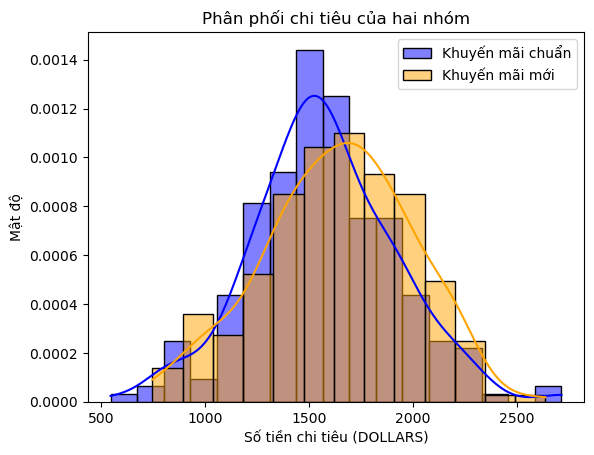


Kiểm định Levene:
T-statistic: 1.0919444862334629
P-value: 0.2965477238322019

Kết quả kiểm định T:
T-statistic: -2.274063178039075
P-value: 0.0233868567346514
Có sự khác biệt có ý nghĩa thống kê giữa hai nhóm.


In [12]:
print("\nPhân tích mô tả:")
print("Nhóm khuyến mãi chuẩn:")
print(group_standard.describe())
print("\nNhóm khuyến mãi mới:")
print(group_new.describe())

sns.histplot(group_standard, kde=True, color='blue', label='Khuyến mãi chuẩn', stat="density")
sns.histplot(group_new, kde=True, color='orange', label='Khuyến mãi mới', stat="density")
plt.title('Phân phối chi tiêu của hai nhóm')
plt.xlabel('Số tiền chi tiêu (DOLLARS)')
plt.ylabel('Mật độ')
plt.legend()
plt.show()

levene_stat, levene_p = stats.levene(group_standard, group_new)
print("\nKiểm định Levene:")
print("T-statistic:", levene_stat)
print("P-value:", levene_p)

# Bước 6: Thực hiện kiểm định Independent-Samples T Test
equal_var = levene_p > 0.05 
t_statistic, p_value = stats.ttest_ind(group_standard, group_new, equal_var=equal_var)

# Bước 7: In kết quả
print("\nKết quả kiểm định T:")
print("T-statistic:", t_statistic)
print("P-value:", p_value)

# Bước 8: Đánh giá kết quả
alpha = 0.05  # Mức ý nghĩa
if p_value < alpha:
    print("Có sự khác biệt có ý nghĩa thống kê giữa hai nhóm.")
else:
    print("Không có sự khác biệt có ý nghĩa thống kê giữa hai nhóm.")